In [15]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
N_TRIALS = 10000
BANDITS = [0.2, 0.5, 0.75]  # The true probabilities of winning for each bandit
EPSILONS = np.linspace(0.01, 0.5, 10)  # The exploration rates to compare

In [17]:
class Bandit:
    def __init__(self, p):
        self.p = p              # The true probability of winning for this bandit
        self.p_estimate = 0.0   # The estimated probability of winning for this bandit
        self.N = 0              # Number of samples collected from this bandit so far
    
    def pull(self):
        # Create a random number between 0 and 1. If the number is less than p, return 1 (reward), else return 0 (no reward)
        return 1 if np.random.random() < self.p else 0
    
    def update(self, x):
        # Update the number of samples and the estimated probability of winning for this bandit
        self.N += 1
        self.p_estimate = ((self.N - 1)*self.p_estimate + x) / self.N

In [18]:
def run_experiment(EPSILON, print_results=False):
    # Generate the bandits with the specified probabilities
    bandits             = [Bandit(p) for p in BANDITS]
    n_times_explored    = 0 
    n_times_exploited   = 0
    n_times_optimal     = 0
    rewards             = []

    # Run the simulation for N_TRIALS
    for trial_indx in np.arange(N_TRIALS):
        # 1] Use epsilon-greedy strategy to select a bandit
        if np.random.random() < EPSILON:
            # Explore: select a random bandit
            bandit_indx = np.random.randint(len(BANDITS))
            n_times_explored += 1 
        else:
            # Exploit: select the bandit with the highest estimated probability of winning
            bandit_indx = np.argmax([b.p_estimate for b in bandits])
            n_times_exploited += 1 

        # 2] Pull the selected bandit and get the reward
        reward = bandits[bandit_indx].pull()
        rewards.append(reward)

        # 3] Update the selected bandit with the received reward
        bandits[bandit_indx].update(reward)

        # 4] Check if the selected bandit is the optimal one (the one with the highest true probability of winning)
        if bandit_indx == np.argmax(BANDITS):
            n_times_optimal += 1

    # Print the p_estimate for each bandit, the number of times each bandit was selected and the total reward
    if print_results:
        for bandit_indx, bandit in enumerate(bandits):
            print(f"Bandit {bandit_indx}: p_estimate = {bandit.p_estimate:.3f}, true p = {bandit.p:.3f}, N = {bandit.N}, N_trials = {N_TRIALS}")

        print(80*"=")
        print(f"The number of times explored = {n_times_explored}")
        print(f"The number of times exploited = {n_times_exploited}")
        print(f"The number of times the optimal bandit was selected = {n_times_optimal}")
        print(f"The total reward = {np.sum(rewards)}")
        print(f"The win rate = {np.sum(rewards)/N_TRIALS:.3f}")

    comulative_rewards = np.cumsum(rewards)
    cumulative_win_rate = comulative_rewards / (np.arange(N_TRIALS) + 1)

    return cumulative_win_rate

In [19]:
epsilon_results = {}
for EPSILON in EPSILONS:
    print(f"Running experiment with EPSILON = {EPSILON}")
    epsilon_results[EPSILON] = run_experiment(EPSILON)

Running experiment with EPSILON = 0.01
Running experiment with EPSILON = 0.06444444444444444
Running experiment with EPSILON = 0.11888888888888888
Running experiment with EPSILON = 0.17333333333333334
Running experiment with EPSILON = 0.22777777777777777
Running experiment with EPSILON = 0.2822222222222222
Running experiment with EPSILON = 0.33666666666666667
Running experiment with EPSILON = 0.3911111111111111
Running experiment with EPSILON = 0.44555555555555554
Running experiment with EPSILON = 0.5


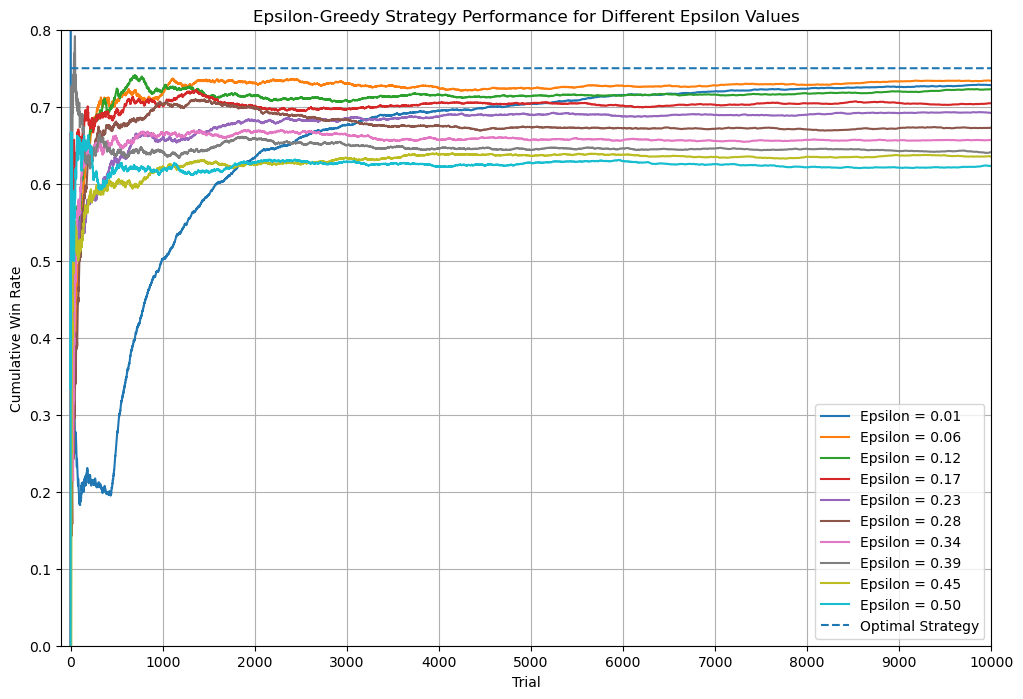

In [29]:
# Plotting the results
plt.figure(figsize=(12, 8))
for EPSILON, cumulative_win_rate in epsilon_results.items():
    plt.plot(cumulative_win_rate, label=f"Epsilon = {EPSILON:.2f}")
plt.plot(np.ones(N_TRIALS)*np.max(BANDITS), label="Optimal Strategy", linestyle="--")
plt.xlabel("Trial")
plt.ylabel("Cumulative Win Rate")
plt.title("Epsilon-Greedy Strategy Performance for Different Epsilon Values")
plt.xlim(0 - 100, N_TRIALS)
plt.ylim(0, np.max(BANDITS) + 0.05)
plt.xticks(np.arange(0, N_TRIALS + 1, 1000))
plt.yticks(np.arange(0, np.max(BANDITS) + 0.1, 0.1))
plt.legend()
plt.grid()
plt.show()